<a href="https://colab.research.google.com/github/Juan-Zavanela/fishmorph-svm/blob/main/FishMorph_Family.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay



In [34]:
path = kagglehub.dataset_download("menegidio/fishmorph-dataset")
print(os.listdir(path))

df = pd.read_csv(os.path.join(path, "FISHMORPH_Family_Dataset.csv"))
print(df.shape)
print(df.columns.tolist())
df.head()

Using Colab cache for faster access to the 'fishmorph-dataset' dataset.
['FISHMORPH_Order_Dataset.csv', 'FISHMORPH_Family_Dataset.csv']
(8342, 11)
['MBl', 'BEl', 'VEp', 'REs', 'OGp', 'RMl', 'BLs', 'PFv', 'PFs', 'CPt', 'Family']


,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt,Family
0,130.0,4.579113,0.622642,0.375019,0.622642,0.868659,0.484981,0.273585,0.144108,3.348991,Cyprinidae
1,11.5,2.796068,0.650700,0.353780,0.509800,0.411157,0.722461,0.330169,0.221095,2.525592,Cichlidae
2,6.6,4.564329,0.518187,0.312002,0.203985,0.413221,0.591495,0.105517,0.188193,2.104580,Cyprinidae
3,10.9,4.390422,0.548247,0.244804,0.168959,0.324728,0.642991,0.097450,0.193049,1.787062,Cyprinidae
4,18.9,4.410271,0.542353,0.292058,0.183790,0.398567,0.685672,0.087643,0.170648,2.968906,Cyprinidae


In [35]:
# Tratamento de dados

print(df.info())
print(df.describe())
print(df.isnull().sum())
df = df.drop_duplicates().dropna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8342 entries, 0 to 8341
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MBl     8342 non-null   float64
 1   BEl     8342 non-null   float64
 2   VEp     8342 non-null   float64
 3   REs     8342 non-null   float64
 4   OGp     8342 non-null   float64
 5   RMl     8342 non-null   float64
 6   BLs     8342 non-null   float64
 7   PFv     8342 non-null   float64
 8   PFs     8342 non-null   float64
 9   CPt     8342 non-null   float64
 10  Family  8342 non-null   object 
dtypes: float64(10), object(1)
memory usage: 717.0+ KB
None
               MBl          BEl          VEp          REs          OGp  \
count  8342.000000  8342.000000  8342.000000  8342.000000  8342.000000   
mean     22.004517     4.452438     0.549087     0.391665     0.381768   
std      33.612007     2.338235     0.094883     0.132814     0.194352   
min       1.200000     1.033084     0.159248     0.00000

Family
Cyprinidae         1545
Cichlidae          1060
Characidae          732
Loricariidae        427
Percidae            190
                   ... 
Sillaginidae          1
Serrasalmidae         1
Bythitidae            1
Vaillantellidae       1
Valenciidae           1
Name: count, Length: 197, dtype: int64


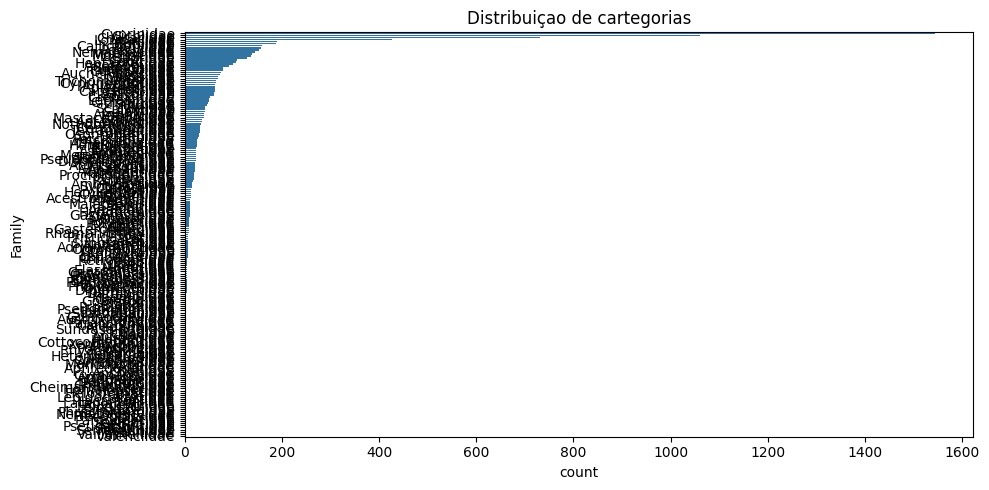

In [36]:
# Distribuido Categorias

alvo = "Family"
print(df[alvo].value_counts())

plt.figure(figsize = (10, 5))
sns.countplot(y = df[alvo], order = df[alvo].value_counts().index)
plt.title("Distribuiçao de cartegorias")
plt.tight_layout()
plt.show()

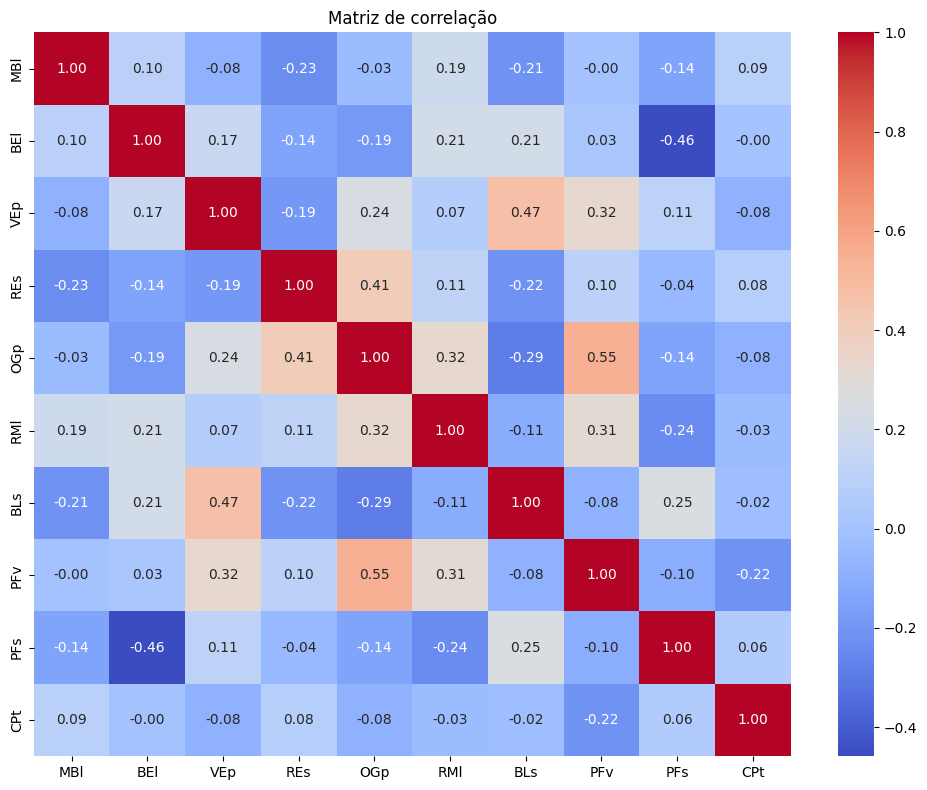

In [23]:
# Matriz de correlaçao

plt.figure( figsize = (10 ,8))
sns.heatmap( df.select_dtypes(include ="number").corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlação")
plt.tight_layout()
plt.show()

In [25]:
# Validaçao de familias

alvo = "Family"
contagem = df[alvo].value_counts()

validas = contagem [contagem >= 20].index
print("Famílias antes:", len(contagem), "| depois:", len(validas))
print("Linhas removidas:", (~df[alvo].isin(validas)).sum())

df = df[df[alvo].isin(validas)]

X = df.drop(columns=[alvo]).select_dtypes(include= "number")
y = df[alvo]

Famílias antes: 197 | depois: 70
Linhas removidas: 612


In [26]:
# Divisao treino e teste

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)

Treino: (6183, 10) | Teste: (1546, 10)


In [28]:
#GridSearch + CrossValidation

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(cache_size=1000)),
])

param = {
    "svm__kernel": ["linear", "poly", "rbf", "sigmoid"],
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": [0.001, 0.01, 0.1, 1],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(pipe, param, cv=cv, scoring="accuracy", n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)


Fitting 3 folds for each of 64 candidates, totalling 192 fits


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC(cache_size=1000))]),
             n_jobs=-1,
             param_grid={'svm__C': [0.1, 1, 10, 100],
                         'svm__gamma': [0.001, 0.01, 0.1, 1],
                         'svm__kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             scoring='accuracy', verbose=1)

In [37]:
# Melhores Parametros
print("Modelo:", grid.best_estimator_.named_steps["svm"])
print("Melhores parâmetros:", grid.best_params_)
print("Acurácia média (validação cruzada):", round(grid.best_score_, 4))
y_pred = grid.predict(X_test)
print("Acurácia no teste:", round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred, zero_division=0))


Modelo: SVC(C=10, cache_size=1000, gamma=0.1)
Melhores parâmetros: {'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Acurácia média (validação cruzada): 0.6785
Acurácia no teste: 0.6889
                   precision    recall  f1-score   support

   Abyssocottidae       1.00      0.25      0.40         4
    Acipenseridae       0.75      0.75      0.75         4
        Alestidae       0.00      0.00      0.00        15
       Ambassidae       1.00      0.80      0.89         5
      Amphiliidae       1.00      0.75      0.86         8
      Anabantidae       1.00      0.25      0.40         4
      Anostomidae       0.36      0.20      0.26        20
    Aplocheilidae       0.36      0.31      0.33        13
    Apteronotidae       0.57      0.57      0.57         7
          Ariidae       0.33      0.33      0.33         9
     Aspredinidae       1.00      0.20      0.33         5
    Astroblepidae       1.00      0.80      0.89         5
   Atherinopsidae       0.80      0.80  

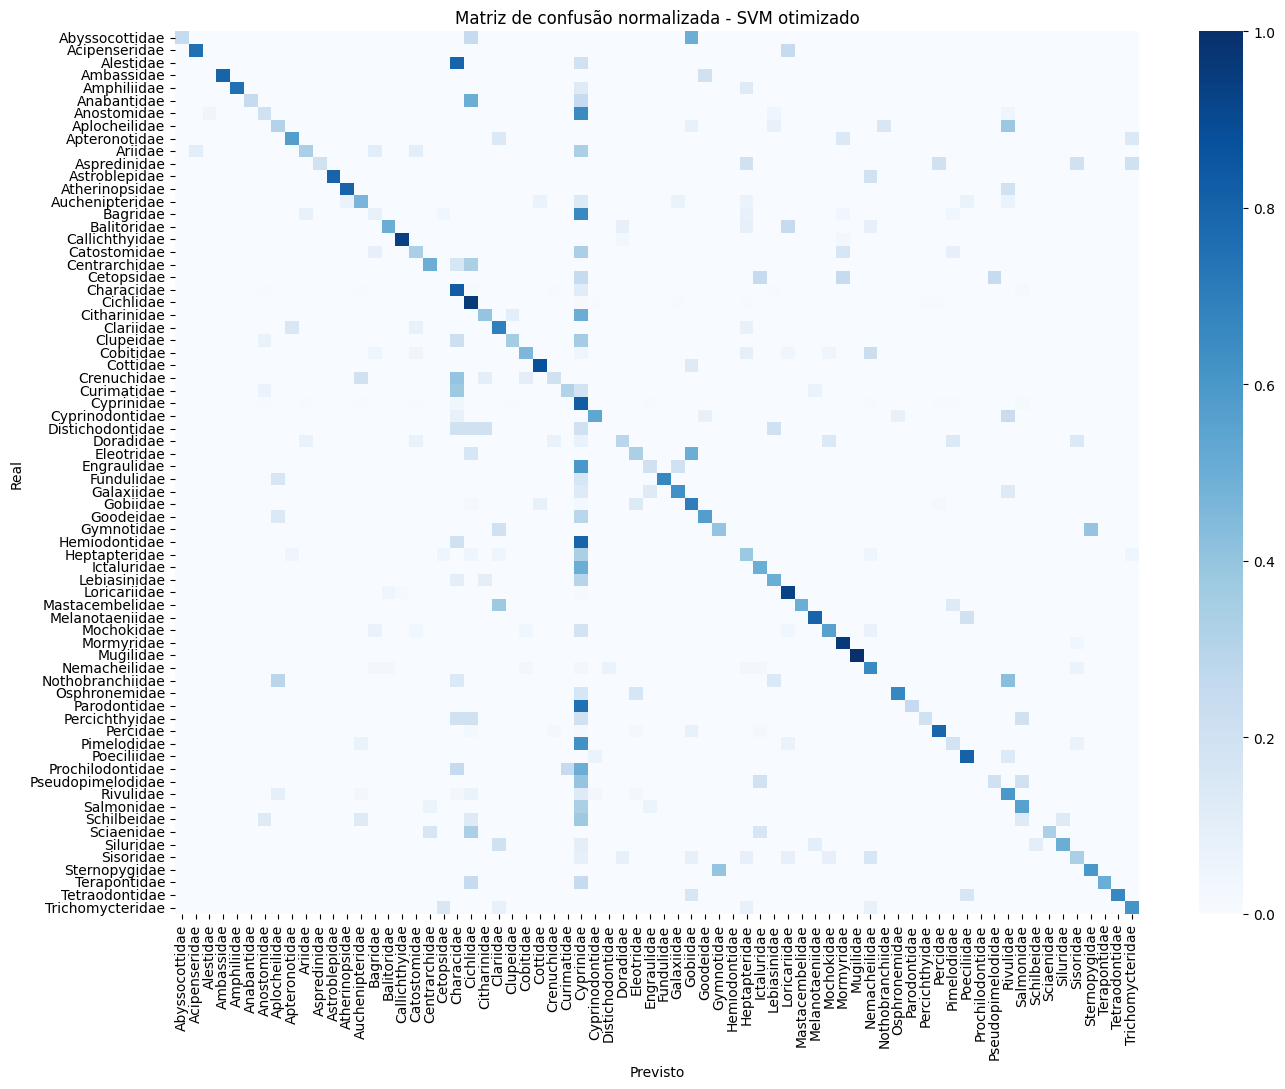

In [38]:
# Matriz de confusao

classes = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=classes, normalize="true")

plt.figure(figsize=(14, 11))
sns.heatmap(cm, cmap="Blues", xticklabels=classes, yticklabels=classes,
            annot=(len(classes) <= 15), fmt=".2f")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de confusão normalizada - SVM otimizado")
plt.tight_layout()
plt.show()